In [1]:
library(tidymodels)
library(mlr3)
library(caret)
library(themis)
library(smotefamily)
library(randomForest)
library(ggplot2)
library(mlflow)
library(skimr)
library(data.table)
library(reticulate)
library(data.table)

py_install("scikit-learn")

library(DoubleML)
library(Matrix)
library(grf)
library(CausalModels)
library(GGally)
library(dplyr)

library(tidyverse)
library(mclust)      # For Gaussian Mixture Models
library(ade4)# For MCA on categorical data  
library(mvtnorm)
library(stringr)
library(fastDummies)
options(warn=-1)


── Attaching packages ────────────────────────────────────────────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.12     ✔ recipes      1.3.1 
✔ dials        1.4.2      ✔ rsample      1.3.2 
✔ dplyr        1.1.4      ✔ tailor       0.1.0 
✔ ggplot2      4.0.2      ✔ tidyr        1.3.1 
✔ infer        1.1.0      ✔ tune         2.0.1 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.4.1      ✔ workflowsets 1.1.1 
✔ purrr        1.2.1      ✔ yardstick    1.3.2 

── Conflicts ───────────────────────────────────────────────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()

Loading required package: lattice


Attaching package: ‘caret’


The following objects are masked from ‘package:yardstick’:

    precision, recall, sensitivity, specificity


The following object is masked from

Using virtual environment '/home/voltsy/.virtualenvs/r-reticulate' ...


+ /home/voltsy/.virtualenvs/r-reticulate/bin/python -m pip install --upgrade --no-user scikit-learn


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.3.1
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ data.table::between()   masks dplyr::between()
✖ readr::col_factor()     masks scales::col_factor()
✖ randomForest::combine() masks dplyr::combine()
✖ purrr::discard()        masks scales::discard()
✖ Matrix::expand()        masks tidyr::expand()
✖ dplyr::filter()         masks stats::filter()
✖ data.table::first()     masks dplyr::first()
✖ stringr::fixed()        masks recipes::fixed()
✖ lubridate::hour()       masks data.table::hou

In [2]:
train_df <- read.csv("data/train.csv")
train_df

PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
0001_01,Europa,False,B/0/P,TRAPPIST-1e,39,False,0,0,0,0,0,Maham Ofracculy,False
0002_01,Earth,False,F/0/S,TRAPPIST-1e,24,False,109,9,25,549,44,Juanna Vines,True
0003_01,Europa,False,A/0/S,TRAPPIST-1e,58,True,43,3576,0,6715,49,Altark Susent,False
0003_02,Europa,False,A/0/S,TRAPPIST-1e,33,False,0,1283,371,3329,193,Solam Susent,False
0004_01,Earth,False,F/1/S,TRAPPIST-1e,16,False,303,70,151,565,2,Willy Santantines,True
0005_01,Earth,False,F/0/P,PSO J318.5-22,44,False,0,483,0,291,0,Sandie Hinetthews,True
0006_01,Earth,False,F/2/S,TRAPPIST-1e,26,False,42,1539,3,0,0,Billex Jacostaffey,True
0006_02,Earth,True,G/0/S,TRAPPIST-1e,28,False,0,0,0,0,NA,Candra Jacostaffey,True
0007_01,Earth,False,F/3/S,TRAPPIST-1e,35,False,0,785,17,216,0,Andona Beston,True


In [3]:
skim(train_df)

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,PassengerId,0,1.0000000,7,7,0,8693,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,HomePlanet,0,1.0000000,0,6,201,4,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,CryoSleep,0,1.0000000,0,5,217,3,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,Cabin,0,1.0000000,0,8,199,6561,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,Destination,0,1.0000000,0,13,182,4,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,VIP,0,1.0000000,0,5,203,3,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,Name,0,1.0000000,0,18,200,8474,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,Transported,0,1.0000000,4,5,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
9,numeric,Age,179,0.9794087,NA,NA,NA,NA,NA,28.82793,14.48902,0,19,27,38,79,▂▇▅▂▁


In [4]:
colnames(train_df)

[1] "PassengerId"  "HomePlanet"   "CryoSleep"    "Cabin"        "Destination" 
 [6] "Age"          "VIP"          "RoomService"  "FoodCourt"    "ShoppingMall"
[11] "Spa"          "VRDeck"       "Name"         "Transported"

## EDA

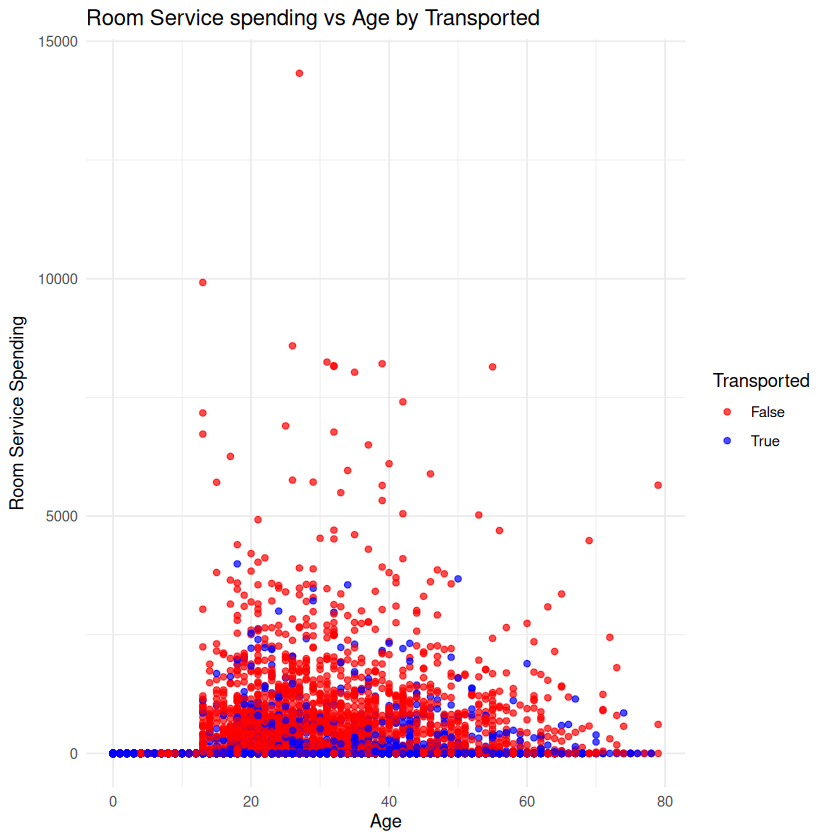

In [5]:
ggplot(train_df, aes(x = Age, y = RoomService, color = Transported)) +
  geom_point(alpha = 0.7) +
  scale_color_manual(values = c("red", "blue")) +
  theme_minimal() +
  labs(
    title = "Room Service spending vs Age by Transported",
    x = "Age",
    y = "Room Service Spending",
    color = "Transported"
  )
ggsave("Visualizations/Room Service spending vs Age by Transported.png", width = 6, height = 4, dpi = 300)

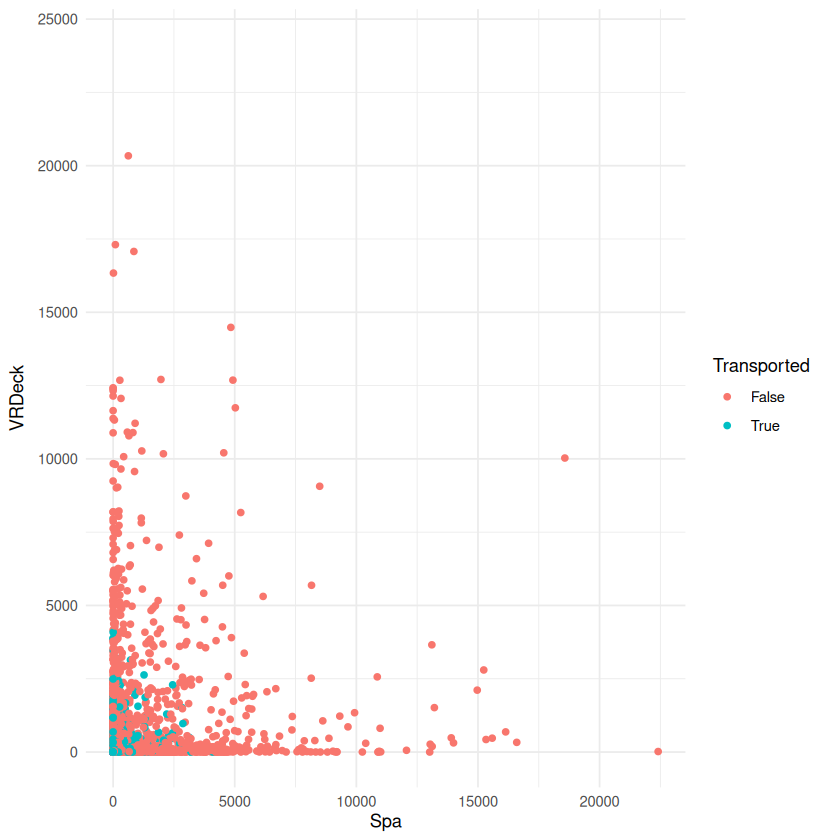

In [6]:
ggplot(train_df, aes(x = Spa, y = VRDeck, color = Transported)) +
  geom_point() +
  theme_minimal()

ggsave("Visualizations/Multiple_Columns.png", width = 6, height = 4, dpi = 300)

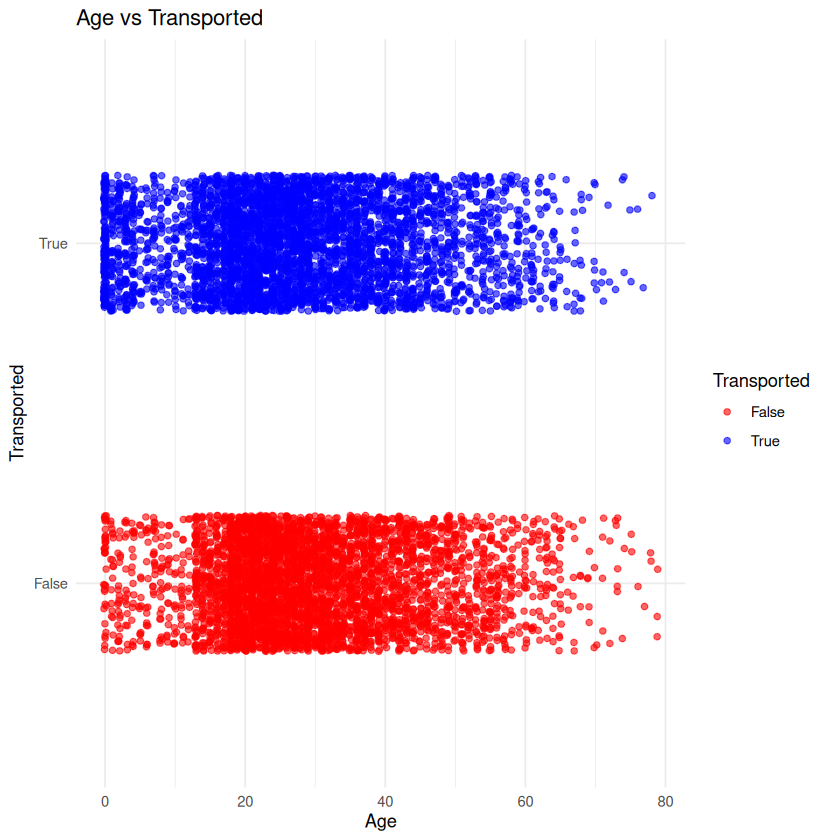

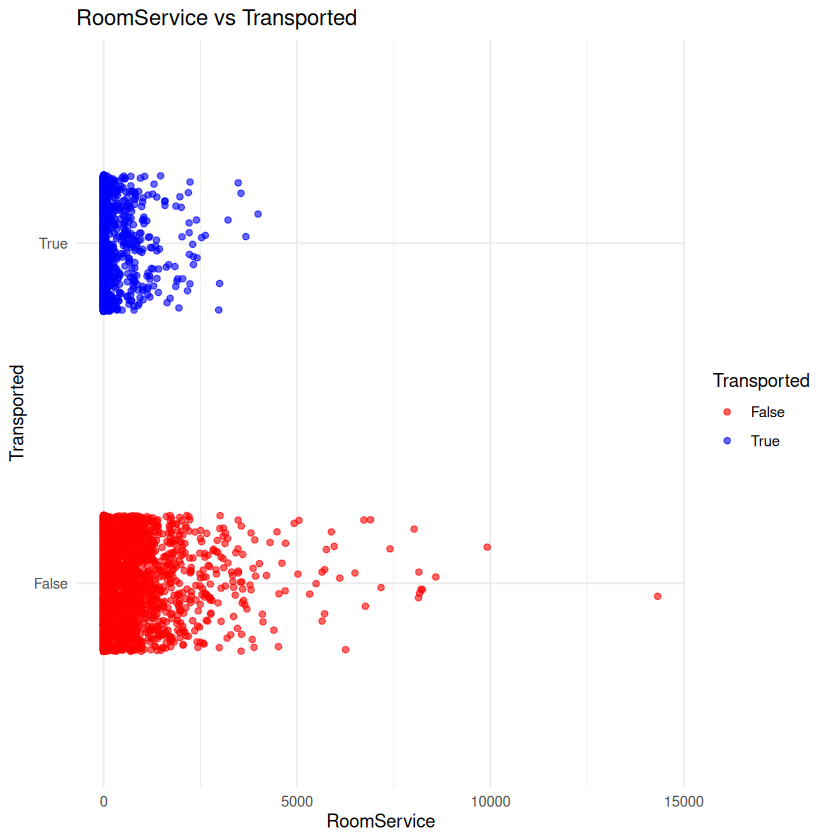

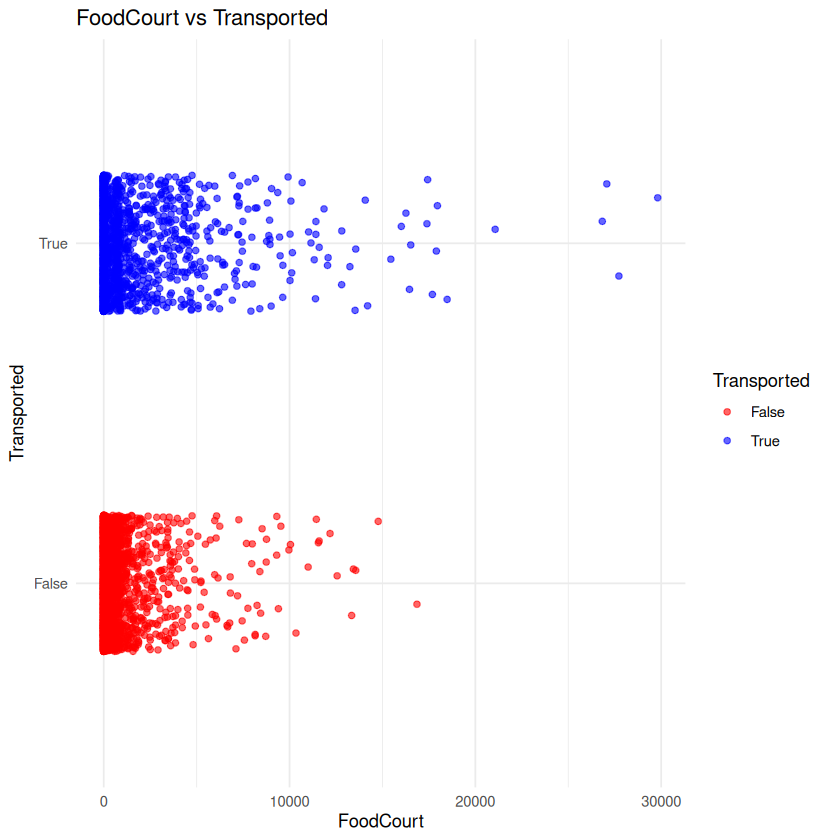

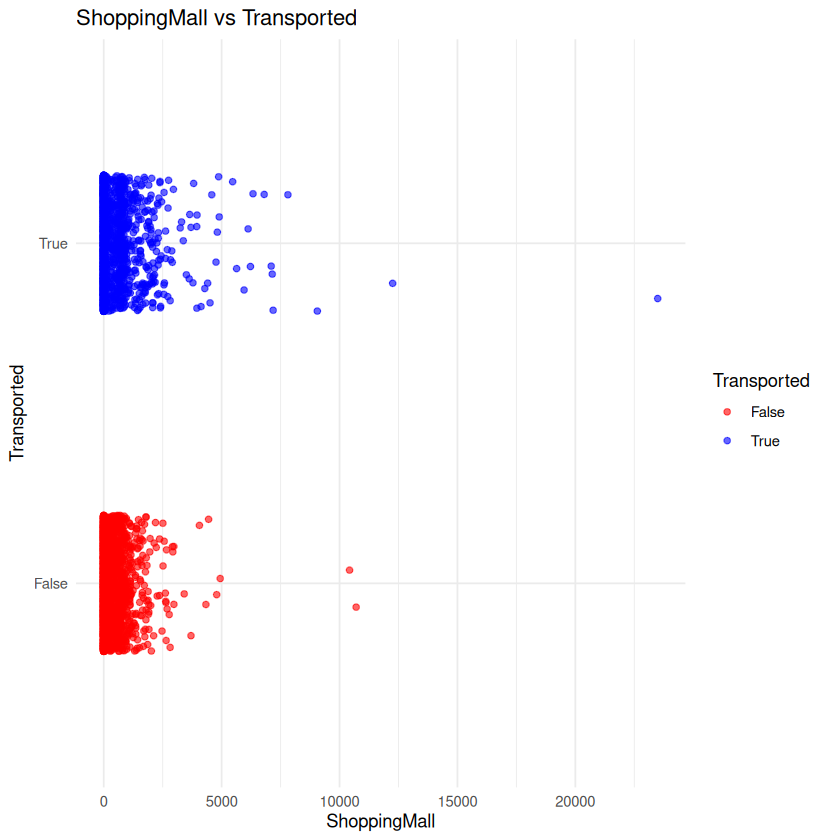

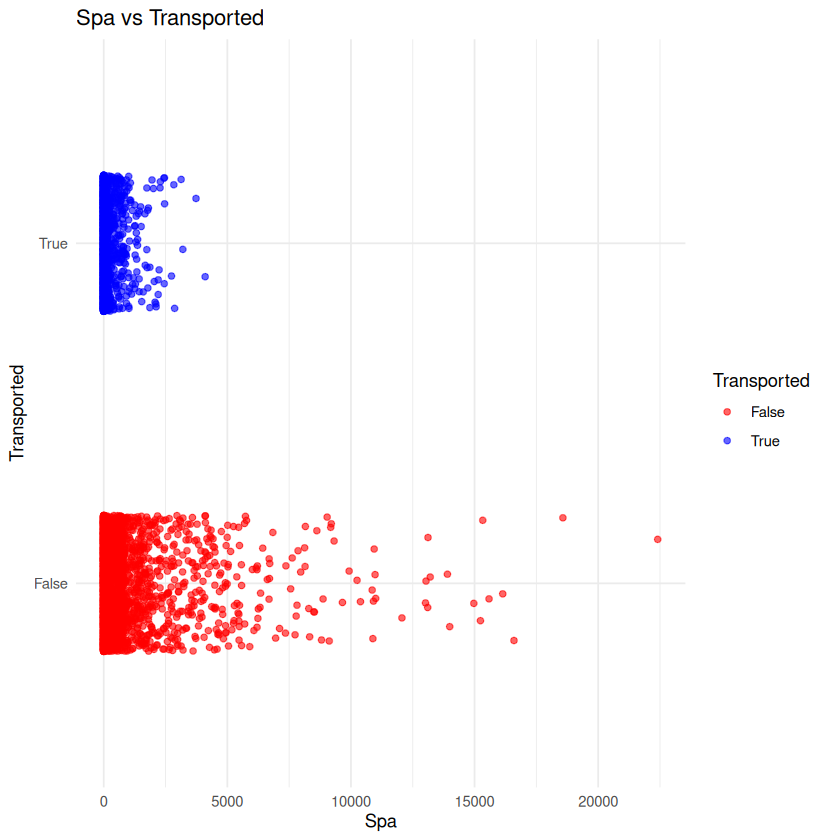

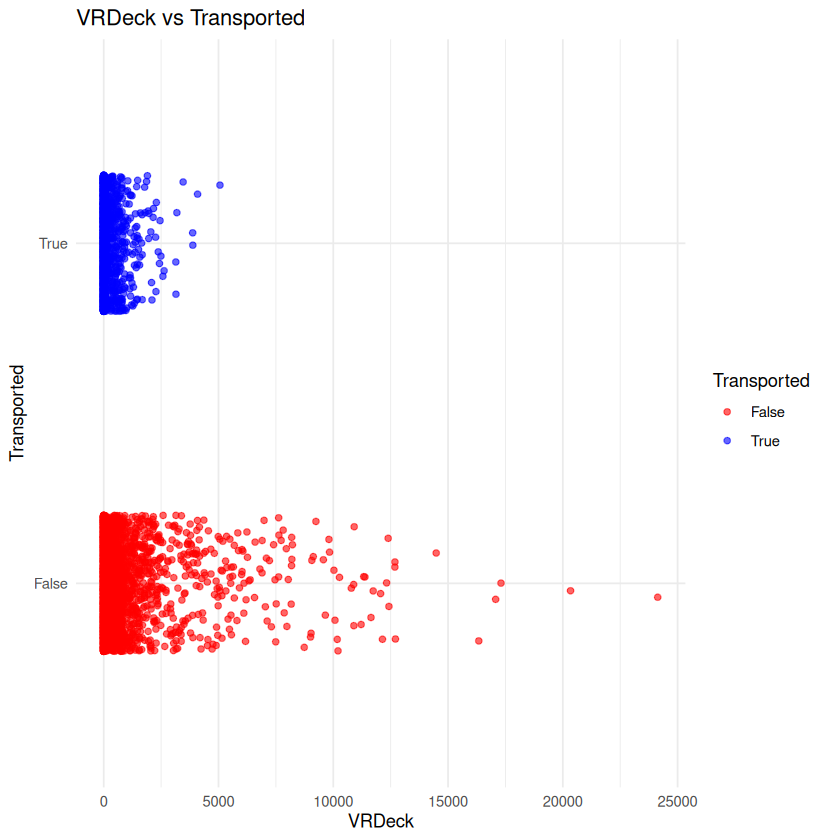

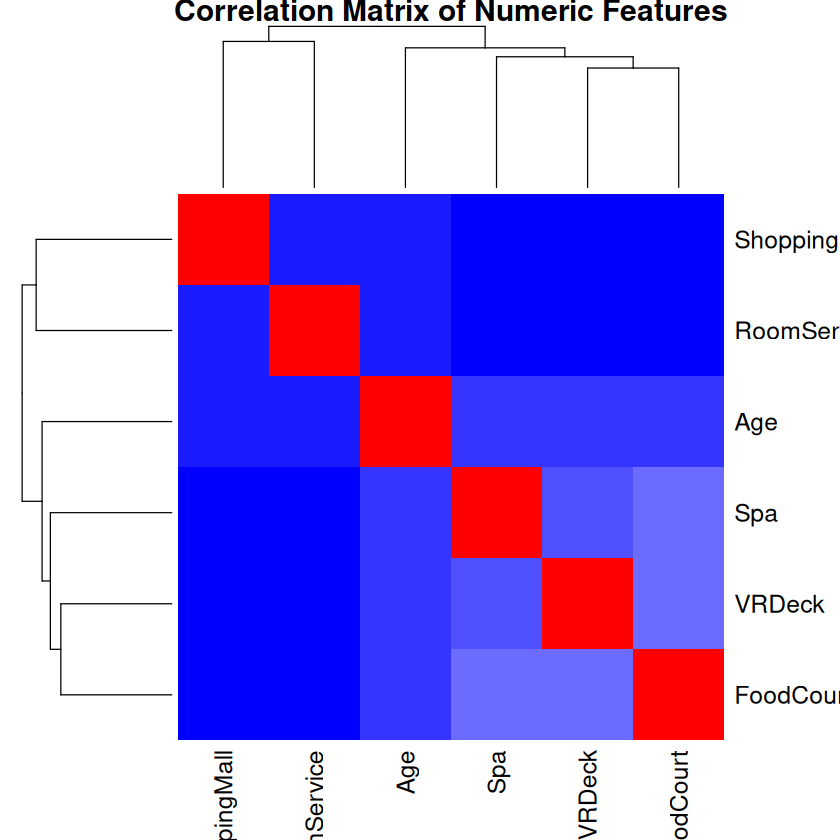

In [7]:
train_df$Transported <- as.factor(train_df$Transported)

numeric_cols <- c("Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck")
numeric_df <- train_df %>% select(all_of(numeric_cols))

# Ensure Transported is a factor
train_df$Transported <- as.factor(train_df$Transported)

for (col in numeric_cols) {
  # Use .data[[col]] instead of aes_string for modern ggplot2
  p <- ggplot(train_df, aes(x = .data[[col]], y = Transported, color = Transported)) +
    geom_jitter(width = 0.2, height = 0.2, alpha = 0.6) +
    theme_minimal() +
    labs(title = paste(col, "vs Transported"),
         x = col, y = "Transported") +
    scale_color_manual(values = c("red", "blue"))
  
  # Corrected string concatenation using paste0
  res <- sprintf("%s", col)
  ggsave(paste0(res, ".png"), plot = p, width = 6, height = 4, dpi = 300)
  
  print(p)
}

cor_matrix <- cor(numeric_df, use = "pairwise.complete.obs")

# Base R heatmap
heatmap(cor_matrix, symm = TRUE, col = colorRampPalette(c("blue", "white", "red"))(20),
        main = "Correlation Matrix of Numeric Features")

## Feature Engineering

In [14]:
prepare_features <- function(df) {

  library(data.table)
  library(reticulate)
  library(uwot)
  library(mclust)

  setDT(df)

  # =====================================
  # sklearn
  # =====================================

  sklearn <- import("sklearn")

  SimpleImputer <- sklearn$impute$SimpleImputer
  LabelEncoder <- sklearn$preprocessing$LabelEncoder

  # =====================================
  # Basic cleanup
  # =====================================

  list_cols <- names(df)[sapply(df, is.list)]

  if (length(list_cols) > 0) {
    df[, (list_cols) := NULL]
  }

  # =====================================
  # Passenger features
  # =====================================

  if ("PassengerId" %in% names(df)) {

    pid_split <- tstrsplit(
      as.character(df$PassengerId),
      "_",
      fixed = TRUE
    )

    df[, GroupID := pid_split[[1]]]

    df[, PassengerNum := suppressWarnings(
      as.integer(pid_split[[2]])
    )]

    df[, GroupSize := .N, by = GroupID]
  }

  # =====================================
  # Cabin features
  # =====================================

  if ("Cabin" %in% names(df)) {

    cabin_split <- tstrsplit(
      as.character(df$Cabin),
      "/",
      fixed = TRUE
    )

    df[, Deck := cabin_split[[1]]]

    df[, CabinNum := suppressWarnings(
      as.numeric(cabin_split[[2]])
    )]

    df[, Side := cabin_split[[3]]]

    df[Side == "P", Side := "Port"]
    df[Side == "S", Side := "Starboard"]

    df[, CabinSection := fifelse(
      is.na(CabinNum),
      "Missing",
      fifelse(
        CabinNum <= 500,
        "Forward",
        fifelse(
          CabinNum <= 1000,
          "Midship",
          fifelse(
            CabinNum <= 1500,
            "Aft",
            "Rear"
          )
        )
      )
    )]
  }

  # =====================================
  # Expense features
  # =====================================

  expense_cols <- intersect(
    c(
      "RoomService",
      "FoodCourt",
      "ShoppingMall",
      "Spa",
      "VRDeck"
    ),
    names(df)
  )

  for (col in expense_cols) {

    df[[col]] <- suppressWarnings(
      as.numeric(df[[col]])
    )

    df[[col]][is.na(df[[col]])] <- 0
  }

  if (length(expense_cols) > 0) {

    df[, TotalExpense := rowSums(
      .SD,
      na.rm = TRUE
    ),
    .SDcols = expense_cols]

    df[, LogTotalExpense :=
         log1p(TotalExpense)]

    df[, NumAmenities :=
         rowSums(.SD > 0),
       .SDcols = expense_cols]
  }

  # =====================================
  # CryoSleep inference
  # =====================================

  if ("CryoSleep" %in% names(df)) {

    df[
      is.na(CryoSleep) &
        TotalExpense == 0,
      CryoSleep := TRUE
    ]

    df[
      is.na(CryoSleep) &
        TotalExpense > 0,
      CryoSleep := FALSE
    ]
  }

  # =====================================
  # Age features
  # =====================================

  if ("Age" %in% names(df)) {

    df[, Age := suppressWarnings(
      as.numeric(Age)
    )]

    age_med <- median(
      df$Age,
      na.rm = TRUE
    )

    if (is.na(age_med)) {
      age_med <- 0
    }

    df[is.na(Age), Age := age_med]

    df[, AgeGroup := cut(
      Age,
      breaks = c(
        0, 12, 18, 35, 60, Inf
      ),
      labels = c(
        "Child",
        "Teen",
        "Adult",
        "MiddleAge",
        "Senior"
      ),
      include.lowest = TRUE
    )]
  }

  # =====================================
  # Column definitions
  # =====================================

  categorical_cols <- intersect(
    c(
      "HomePlanet",
      "CryoSleep",
      "Destination",
      "VIP",
      "Deck",
      "Side",
      "CabinSection",
      "AgeGroup",
      "GroupID"
    ),
    names(df)
  )

  numeric_cols <- names(df)[
    sapply(df, is.numeric)
  ]

  numeric_cols <- setdiff(
    numeric_cols,
    c("Transported")
  )

  # =====================================
  # SAFE MODE FUNCTION
  # =====================================

  safe_mode <- function(x) {

    x <- x[!is.na(x)]

    if (length(x) == 0) {
      return("Missing")
    }

    ux <- unique(x)

    ux[
      which.max(tabulate(match(x, ux)))
    ]
  }

  # =====================================
  # Categorical cleaning
  # =====================================

  for (col in categorical_cols) {

    x <- as.character(df[[col]])

    x[is.na(x)] <- "Missing"

    x <- iconv(
      x,
      from = "",
      to = "UTF-8",
      sub = ""
    )

    x <- gsub(
      "[[:cntrl:]]",
      "",
      x
    )

    x <- substr(x, 1, 100)

    x[trimws(x) == ""] <- "Missing"

    x[x %in% c(
      "NA",
      "NaN",
      "NULL",
      "None"
    )] <- "Missing"

    mode_value <- safe_mode(x)

    x[is.na(x)] <- mode_value

    Encoding(x) <- "UTF-8"

    df[[col]] <- x
  }

  # =====================================
  # Numeric imputation
  # =====================================

  if (length(numeric_cols) > 0) {

    num_imputer <- SimpleImputer(
      strategy = "median"
    )

    num_input <- as.matrix(
      df[, ..numeric_cols]
    )

    mode(num_input) <- "numeric"

    num_input[
      is.infinite(num_input)
    ] <- NA

    num_imputed <- num_imputer$fit_transform(
      num_input
    )

    num_imputed <- as.data.frame(
      num_imputed
    )

    df[, (numeric_cols) :=
         as.data.table(num_imputed)]
  }

  # =====================================
  # Hidden Regime Features
  # =====================================

  if (nrow(df) > 10) {

    regime_numeric_cols <- names(df)[
      sapply(df, is.numeric)
    ]

    regime_numeric_cols <- setdiff(
      regime_numeric_cols,
      c("Transported")
    )

    regime_matrix <- as.matrix(
      df[, ..regime_numeric_cols]
    )

    mode(regime_matrix) <- "numeric"

    regime_matrix[
      is.na(regime_matrix)
    ] <- 0

    regime_matrix[
      is.infinite(regime_matrix)
    ] <- 0

    # -----------------------------
    # UMAP embedding
    # -----------------------------

    umap_embedding <- uwot::umap(
      regime_matrix,
      n_neighbors = 15,
      min_dist = 0.05,
      metric = "euclidean",
      n_components = 2,
      verbose = FALSE
    )

    df[, UMAP1 := umap_embedding[, 1]]
    df[, UMAP2 := umap_embedding[, 2]]

    # -----------------------------
    # Gaussian Mixture Regimes
    # -----------------------------

    gmm_model <- Mclust(
      umap_embedding,
      G = 4,
      verbose = FALSE
    )

    df[, HiddenRegime :=
         as.integer(gmm_model$classification)]

    regime_probs <- as.data.table(
      gmm_model$z
    )

    setnames(
      regime_probs,
      paste0(
        "RegimeProb_",
        seq_len(ncol(regime_probs))
      )
    )

    df <- cbind(
      df,
      regime_probs
    )

    # -----------------------------
    # Entropy
    # -----------------------------

    prob_matrix <- as.matrix(
      regime_probs
    )

    entropy <- apply(
      prob_matrix,
      1,
      function(p) {

        p <- p + 1e-9

        -sum(p * log(p))
      }
    )

    df[, RegimeEntropy := entropy]

    # -----------------------------
    # Confidence
    # -----------------------------

    df[, RegimeConfidence :=
         apply(prob_matrix, 1, max)]

    # -----------------------------
    # Interaction features
    # -----------------------------

    if ("TotalExpense" %in% names(df)) {

      df[, RegimeExpenseInteraction :=
           HiddenRegime * TotalExpense]
    }

    if ("Age" %in% names(df)) {

      df[, RegimeAgeInteraction :=
           HiddenRegime * Age]
    }
  }

  # =====================================
  # Diagnostics
  # =====================================

  for (col in categorical_cols) {

    cat(
      "\nCOLUMN:", col,
      "\nMAX LEN:",
      max(nchar(df[[col]]), na.rm = TRUE),
      "\nUNIQUE:",
      length(unique(df[[col]])),
      "\n"
    )
  }

  # =====================================
  # Label Encoding
  # =====================================

  for (col in categorical_cols) {

    le <- LabelEncoder()

    vals <- as.character(df[[col]])

    vals[is.na(vals)] <- "Missing"

    vals <- substr(vals, 1, 100)

    vals[trimws(vals) == ""] <- "Missing"

    df[[col]] <- as.integer(
      le$fit_transform(vals)
    )
  }

  # =====================================
  # Final cleanup
  # =====================================

  drop_cols <- intersect(
    c(
      "Cabin",
      "Name",
      "PassengerId"
    ),
    names(df)
  )

  if (length(drop_cols) > 0) {
    df[, (drop_cols) := NULL]
  }

  # Remove infinite values

  for (col in names(df)) {

    if (is.numeric(df[[col]])) {

      df[[col]][
        is.infinite(df[[col]])
      ] <- NA_real_
    }
  }

  return(df)
}

In [15]:
process_spaceship_data <- function(
  train_path,
  test_path
) {

  # =========================
  # Load Data
  # =========================

  train_df <- fread(train_path)

  test_df <- fread(test_path)

  # =========================
  # Feature Engineering
  # =========================

  train_df <- prepare_features(train_df)

  test_df <- prepare_features(test_df)

  # =========================
  # Train Regime Models
  # =========================

  gmm_model <- train_gmm_regimes(
    train_df,
    n_regimes = 3
  )

  kmeans_model <- train_onehot_kmeans_regimes(
    train_df,
    n_regimes = 3
  )

  # =========================
  # Apply GMM Regimes
  # =========================

  train_gmm <- apply_gmm_regimes(
    train_df,
    gmm_model
  )

  test_gmm <- apply_gmm_regimes(
    test_df,
    gmm_model
  )

  # =========================
  # Apply KMeans Regimes
  # =========================

  train_km <- apply_onehot_kmeans_regimes(
    train_df,
    kmeans_model
  )

  test_km <- apply_onehot_kmeans_regimes(
    test_df,
    kmeans_model
  )

  # =========================
  # Bind Regime Features
  # =========================

  train_df <- cbind(
    train_df,
    train_gmm,
    train_km
  )

  test_df <- cbind(
    test_df,
    test_gmm,
    test_km
  )

  # =========================
  # Logical Regimes
  # =========================

  train_df <- compute_logical_regimes(
    train_df
  )

  test_df <- compute_logical_regimes(
    test_df
  )

  # =========================
  # Ensemble Regimes
  # =========================

  train_df <- ensemble_regime_probs(
    train_df
  )

  test_df <- ensemble_regime_probs(
    test_df
  )

  return(list(
    train = train_df,
    test = test_df,
    gmm_model = gmm_model,
    kmeans_model = kmeans_model
  ))
}

In [16]:
# Run the pipeline
result <- process_spaceship_data("data/train.csv", "data/test.csv")

# Extract processed datasets
train_processed <- result$train
test_processed <- result$test

# Check the new regime probability features
grep("Regime|Prob", names(train_processed), value = TRUE)

# Save processed datasets
write.csv(train_processed, "train_with_regimes.csv", row.names = FALSE)
write.csv(test_processed, "test_with_regimes.csv", row.names = FALSE)


COLUMN: HomePlanet 
MAX LEN: 7 
UNIQUE: 4 

COLUMN: CryoSleep 
MAX LEN: 5 
UNIQUE: 2 

COLUMN: Destination 
MAX LEN: 13 
UNIQUE: 4 

COLUMN: VIP 
MAX LEN: 7 
UNIQUE: 3 

COLUMN: Deck 
MAX LEN: 7 
UNIQUE: 9 

COLUMN: Side 
MAX LEN: 9 
UNIQUE: 3 

COLUMN: CabinSection 
MAX LEN: 7 
UNIQUE: 5 

COLUMN: AgeGroup 
MAX LEN: 9 
UNIQUE: 5 

COLUMN: GroupID 
MAX LEN: 4 
UNIQUE: 6217 

COLUMN: HomePlanet 
MAX LEN: 7 
UNIQUE: 4 

COLUMN: CryoSleep 
MAX LEN: 5 
UNIQUE: 2 

COLUMN: Destination 
MAX LEN: 13 
UNIQUE: 4 

COLUMN: VIP 
MAX LEN: 7 
UNIQUE: 3 

COLUMN: Deck 
MAX LEN: 7 
UNIQUE: 9 

COLUMN: Side 
MAX LEN: 9 
UNIQUE: 3 

COLUMN: CabinSection 
MAX LEN: 7 
UNIQUE: 5 

COLUMN: AgeGroup 
MAX LEN: 9 
UNIQUE: 5 

COLUMN: GroupID 
MAX LEN: 4 
UNIQUE: 3063 


ERROR: Error in train_gmm_regimes(train_df, n_regimes = 3): could not find function "train_gmm_regimes"


## Modelling

In [ ]:
train_processed

In [ ]:
set.seed(42)

target_col <- "Transported"
idx <- sample(nrow(train_processed), size=0.8 * nrow(train_processed))

train_data <- train_processed[idx, ]
test_data  <- train_processed[-idx, ]

# y vectors
y_train <- train_data[[target_col]]
y_test  <- test_data[[target_col]]

# remove target from X
train_data[[target_col]] <- NULL
test_data[[target_col]] <- NULL

# convert to sparse matrices
X_train <- Matrix::sparse.model.matrix(
  ~ . - 1,
  data = train_data
)

X_test <- Matrix::sparse.model.matrix(
  ~ . - 1,
  data = test_data
)

In [ ]:
#Imputation
sklearn <- import("sklearn")

SimpleImputer <- sklearn$impute$SimpleImputer
LabelEncoder <- sklearn$preprocessing$LabelEncoder


In [ ]:
X_train_dense <- as.matrix(X_train)

smote_data <- SMOTE(
  X = X_train_dense,
  target = y_train,
  K = 5
)

smote_df <- as.data.frame(smote_data$data)

X_train_smote <- smote_df[, !(names(smote_df) %in% "class")]

y_train_smote <- smote_df$class

In [ ]:
mlflow_set_tracking_uri("mlruns")

mlflow_experiment("spaceship_titanic_regime_models")


with(mlflow_start_run(run_name = "Logistic_Regression"), {

  lr_model <- cv.glmnet(
    x = X_train_smote,
    y = y_train_smote_num,
    family = "binomial",
    alpha = 0
  )

  preds_prob <- predict(
    lr_model,
    X_valid,
    s = "lambda.min",
    type = "response"
  )

  preds <- ifelse(preds_prob > 0.5, 1, 0)

  acc <- Accuracy(y_pred = preds, y_true = y_valid_num)

  mlflow_log_metric("accuracy", acc)

  mlflow_log_param("model", "glmnet")

  saveRDS(lr_model, "lr_model.rds")

  mlflow_log_artifact("lr_model.rds")
})


with(mlflow_start_run(run_name = "Random_Forest"), {

  rf_model <- randomForest(
    x = as.matrix(X_train_smote),
    y = y_train_smote,
    ntree = 200,
    maxnodes = 30
  )

  preds <- predict(
    rf_model,
    as.matrix(X_valid)
  )

  acc <- Accuracy(
    y_pred = preds,
    y_true = y_valid
  )

  mlflow_log_metric("accuracy", acc)

  mlflow_log_param("ntree", 200)

  saveRDS(rf_model, "rf_model.rds")

  mlflow_log_artifact("rf_model.rds")
})

with(mlflow_start_run(run_name = "XGBoost"), {

  dtrain <- xgb.DMatrix(
    data = X_train_smote,
    label = y_train_smote_num
  )

  dvalid <- xgb.DMatrix(
    data = X_valid,
    label = y_valid_num
  )

  xgb_model <- xgboost(
    data = dtrain,
    nrounds = 300,
    max_depth = 6,
    eta = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    objective = "binary:logistic",
    eval_metric = "logloss",
    tree_method = "hist",
    nthread = 2,
    verbose = 0
  )

  preds_prob <- predict(
    xgb_model,
    dvalid
  )

  preds <- ifelse(preds_prob > 0.5, 1, 0)

  acc <- Accuracy(
    y_pred = preds,
    y_true = y_valid_num
  )

  mlflow_log_metric("accuracy", acc)

  mlflow_log_param("max_depth", 6)
  mlflow_log_param("eta", 0.05)

  xgb.save(
    xgb_model,
    "xgb_model.json"
  )

  mlflow_log_artifact("xgb_model.json")
})



with(mlflow_start_run(run_name = "LightGBM"), {

  lgb_train <- lgb.Dataset(
    data = X_train_smote,
    label = y_train_smote_num
  )

  lgb_model <- lightgbm(
    data = lgb_train,
    objective = "binary",
    learning_rate = 0.05,
    num_leaves = 31,
    nrounds = 300,
    num_threads = 2,
    verbose = -1
  )

  preds_prob <- predict(
    lgb_model,
    X_valid
  )

  preds <- ifelse(preds_prob > 0.5, 1, 0)

  acc <- Accuracy(
    y_pred = preds,
    y_true = y_valid_num
  )

  mlflow_log_metric("accuracy", acc)

  mlflow_log_param("num_leaves", 31)

  lgb.save(
    lgb_model,
    "lgb_model.txt"
  )

  mlflow_log_artifact("lgb_model.txt")
})



with(mlflow_start_run(run_name = "CatBoost"), {

  train_pool <- catboost.load_pool(
    data = as.data.frame(as.matrix(X_train_smote)),
    label = y_train_smote_num
  )

  valid_pool <- catboost.load_pool(
    data = as.data.frame(as.matrix(X_valid)),
    label = y_valid_num
  )

  cat_model <- catboost.train(
    learn_pool = train_pool,
    params = list(
      loss_function = "Logloss",
      iterations = 300,
      depth = 6,
      learning_rate = 0.05,
      thread_count = 2
    )
  )

  preds_prob <- catboost.predict(
    cat_model,
    valid_pool,
    prediction_type = "Probability"
  )

  preds <- ifelse(preds_prob > 0.5, 1, 0)

  acc <- Accuracy(
    y_pred = preds,
    y_true = y_valid_num
  )

  mlflow_log_metric("accuracy", acc)

  mlflow_log_param("depth", 6)

  catboost.save_model(
    cat_model,
    "cat_model.cbm"
  )

  mlflow_log_artifact("cat_model.cbm")
})

test_ids <- test_df$PassengerId

if("Transported" %in% names(test_df)) {
  test_df$Transported <- NULL
}

for(col in names(test_df)) {

  if(is.character(test_df[[col]])) {
    test_df[[col]] <- as.factor(test_df[[col]])
  }
}

X_test <- sparse.model.matrix(
  ~ . - 1,
  data = test_df
)


dtest <- xgb.DMatrix(X_test)

xgb_preds_prob <- predict(
  xgb_model,
  dtest
)

xgb_preds <- xgb_preds_prob > 0.5

submission <- data.frame(
  PassengerId = test_ids,
  Transported = xgb_preds
)

write.csv(
  submission,
  "submission.csv",
  row.names = FALSE
)

print(head(submission))


cat("\nTraining Complete.\n")
cat("Submission file saved as submission.csv\n")